# 01 — Data & Exploratory Analysis

This notebook loads the MovieLens-1M dataset and establishes the facts that
drive every methodology decision made later in the project: how the
train/validation/test split is built (`02_evaluation_setup.ipynb`), how a
"relevant" recommendation is defined, and how user-history segments are
chosen for the product analysis (`04_product_analysis.ipynb`).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
FIG_DIR = "../reports/figures"

## 1. Load data

In [2]:
users, movies, ratings = D.load_raw("../data")
ratings, user_id_to_idx, item_id_to_idx = D.add_index_columns(ratings)
print(users.shape, movies.shape, ratings.shape)
ratings.head()

(6040, 5) (3883, 3) (1000209, 6)


,user_id,movie_id,rating,timestamp,user_idx,item_idx
0,1,1193,5,2000-12-31 22:12:40,0,1104
1,1,661,3,2000-12-31 22:35:09,0,639
2,1,914,3,2000-12-31 22:32:48,0,853
3,1,3408,4,2000-12-31 22:04:35,0,3177
4,1,2355,5,2001-01-06 23:38:11,0,2162


In [3]:
print("Missing values:")
print(users.isna().sum().sum(), movies.isna().sum().sum(), ratings.isna().sum().sum())
print("Duplicate rating rows:", ratings.duplicated(subset=["user_id", "movie_id"]).sum())

Missing values:
0 0 0
Duplicate rating rows: 0


No missing values and no duplicate (user, movie) pairs — the raw data is clean.

## 2. Rating distribution and the definition of a "relevant" recommendation

The project evaluates recommenders as *ranking* systems: for a held-out
period, did the model rank the movies the user actually turned out to like
near the top? That requires a binary definition of "liked" from the 1–5
explicit rating scale — a rating of 1 clearly should not count as a
successful recommendation just because the user happened to watch that movie.

We use **relevant = rating ≥ 4** for every model and every evaluation split.
The distribution below is what that choice is based on.

rating
1     5.62
2    10.75
3    26.11
4    34.89
5    22.63
Name: proportion, dtype: float64



Share of ratings >= 3: 83.6%
Share of ratings >= 4: 57.5%
Mean: 3.58  Median: 4  Mode: 4


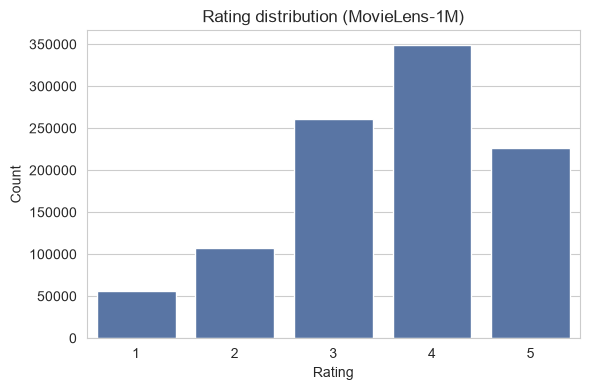

In [4]:
rating_share = ratings["rating"].value_counts(normalize=True).sort_index() * 100
print(rating_share.round(2))
print()
print(f"Share of ratings >= 3: {(ratings.rating >= 3).mean():.1%}")
print(f"Share of ratings >= 4: {(ratings.rating >= 4).mean():.1%}")
print(f"Mean: {ratings.rating.mean():.2f}  Median: {ratings.rating.median():.0f}  Mode: {ratings.rating.mode()[0]:.0f}")

plt.figure(figsize=(6, 4))
sns.countplot(x="rating", data=ratings, color="#4C72B0")
plt.title("Rating distribution (MovieLens-1M)")
plt.xlabel("Rating"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/rating_distribution.png", dpi=150)
plt.show()

**Why `rating >= 4`, not `>= 3`:**

- The distribution is skewed toward high ratings (mode = 4, median = 4, mean ≈ 3.58), so `rating >= 3` would mark **83.6%** of all interactions as "relevant" — too lenient to be a useful ranking target, since it would barely distinguish a genuinely liked movie from a lukewarm one.
- `rating >= 4` marks **57.5%** of interactions as relevant: a majority-positive but non-degenerate split that matches the intuitive reading of the MovieLens scale (4–5 = "liked it", 1–3 = "didn't" or "neutral").
- This threshold is applied identically to every model's ground truth, in every split (validation and test) — see `02_evaluation_setup.ipynb`.

This is a judgment call, not a provable optimum — it is stated explicitly so the reader can evaluate it, and it is applied uniformly so no model is favored by the choice.

## 3. User activity: how much history does a user bring?

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
90%       400.000000
99%       906.660000
max      2314.000000
Name: n_ratings, dtype: float64


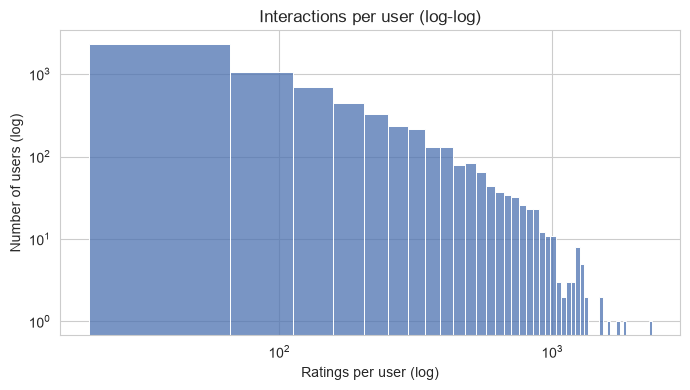

In [5]:
user_activity = ratings.groupby("user_id").size().rename("n_ratings")
print(user_activity.describe(percentiles=[.25, .5, .75, .9, .99]))

plt.figure(figsize=(7, 4))
sns.histplot(user_activity, bins=50, color="#4C72B0")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Ratings per user (log)"); plt.ylabel("Number of users (log)")
plt.title("Interactions per user (log-log)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/interactions_per_user.png", dpi=150)
plt.show()

MovieLens-1M only includes users with **at least 20 ratings** — the minimum
above is exactly 20. This matters methodologically: it means genuine
*user* cold start (someone with 0–2 interactions) essentially does not occur
in this dataset. "Cold" in the segment analysis later means *relatively*
low-history within this already-active population, not a brand-new user —
a limitation discussed explicitly in `04_product_analysis.ipynb`.

Activity is still heavy-tailed: the median user has 96 ratings, but the top
1% have 900+. This range (roughly 20 to 2,300 ratings) is what motivates
segmenting users by history size in the product analysis.

## 4. Item popularity and item cold start

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
90%       729.500000
99%      1784.900000
max      3428.000000
Name: n_ratings, dtype: float64

Movies with < 5 ratings: 7.8%
Movies with zero ratings at all (not in `ratings`): 177


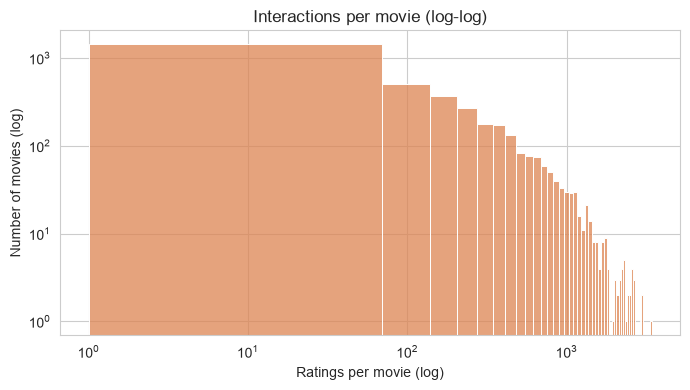

In [6]:
item_activity = ratings.groupby("movie_id").size().rename("n_ratings")
print(item_activity.describe(percentiles=[.25, .5, .75, .9, .99]))
print(f"\nMovies with < 5 ratings: {(item_activity < 5).mean():.1%}")
print(f"Movies with zero ratings at all (not in `ratings`): {movies['movie_id'].nunique() - item_activity.shape[0]}")

plt.figure(figsize=(7, 4))
sns.histplot(item_activity, bins=50, color="#DD8452")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Ratings per movie (log)"); plt.ylabel("Number of movies (log)")
plt.title("Interactions per movie (log-log)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/interactions_per_item.png", dpi=150)
plt.show()

Unlike users, movies show a real cold-start problem: **~7.8% of rated movies
have fewer than 5 ratings**, and a further 177 movies in the catalog have
*zero* ratings at all. Collaborative signals are unreliable or unavailable
for this long tail — one of the reasons a content-based signal (genres,
available for every movie regardless of how often it was rated) is included
in the model comparison.

## 5. Matrix sparsity

In [7]:
n_users = ratings["user_id"].nunique()
n_items = ratings["movie_id"].nunique()
sparsity = 1 - len(ratings) / (n_users * n_items)
print(f"{n_users} users x {n_items} rated movies, sparsity = {sparsity:.4%}")

6040 users x 3706 rated movies, sparsity = 95.5316%


Only about 4.5% of user-movie pairs are observed. This is the core structural
challenge for the item-based and factorization models evaluated later: most
pairs of users share very little rated history.

## 6. Genres: volume vs. average rating

In [8]:
genre_df = (
    movies.assign(genre=movies["genres"].str.split("|"))
    .explode("genre")
    .merge(ratings, on="movie_id")
)
genre_summary = genre_df.groupby("genre").agg(n_ratings=("rating", "size"), avg_rating=("rating", "mean"))
genre_summary.sort_values("n_ratings", ascending=False).round(2)

,n_ratings,avg_rating
genre,,
Comedy,356580,3.52
Drama,354529,3.77
Action,257457,3.49
Thriller,189680,3.57
Sci-Fi,157294,3.47
Romance,147523,3.61
Adventure,133953,3.48
Crime,79541,3.71
Horror,76386,3.22


The most-rated genres (Comedy, Drama, Action) are not the highest-rated ones
(Film-Noir, Documentary, War) — popularity and quality diverge. This is a
first hint at the popularity-vs-diversity trade-off analyzed properly in
`03_models.ipynb`/`04_product_analysis.ipynb`: always recommending the most
popular genres would not surface the content users rate most highly.

## 7. Temporal structure

In [9]:
by_year = ratings["timestamp"].dt.year.value_counts().sort_index()
print(by_year)
print(f"\nDate range: {ratings.timestamp.min().date()} to {ratings.timestamp.max().date()}")

timestamp
2000    904757
2001     68058
2002     24046
2003      3348
Name: count, dtype: int64

Date range: 2000-04-25 to 2003-02-28


Rating activity is concentrated in a short window (late 2000 – early 2003)
and is not remotely uniform across time. A random train/test split of
individual ratings would let a model "see the future" relative to some of
its training users; a **chronological, per-user split** (used from
`02_evaluation_setup.ipynb` onward) is the only setup consistent with the
real recommendation task: predict what a user does *next*, given what they
did *before*.

## Summary — what this EDA implies for the rest of the project

1. **Relevance definition:** `rating >= 4` (57.5% positive rate) — used for every model, every split.
2. **Split design:** chronological, per user (see `02_evaluation_setup.ipynb`) — required by the strong temporal structure of the data.
3. **User cold start is effectively absent** in MovieLens-1M (min. 20 ratings/user); segments in `04_product_analysis.ipynb` describe *relative*, not absolute, history size.
4. **Item cold start is real** (~7.8% of movies have <5 ratings, 177 have none) — motivating a content-based signal that does not depend on collaborative volume.
5. **Popularity and quality are not the same axis** — a recurring theme when comparing a popularity baseline against personalized models.